In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import joblib, gc

FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size',
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration',
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count'
]
NOMBRE_CLASE_BENIGNA = 'BenignTraffic'

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
df = pd.read_feather('Z:/TFG-Alvarez_Julian/IDS-IOT/data/df_binary_balanced.feather')
df['label_binario'] = (df['label'] != NOMBRE_CLASE_BENIGNA).astype(int)
print('Shape:', df.shape)
print(df['label_binario'].value_counts())


Shape: (1976752, 48)
label_binario
0    988376
1    988376
Name: count, dtype: int64


In [3]:
X = df[FEATURES_SELECCIONADAS].values
y = df['label_binario'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=2/9, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

del df; gc.collect()

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'Features: {X_train.shape[1]}')


Train: 1,383,725  Val: 395,351  Test: 197,676
Features: 18


In [4]:
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal Loss binaria.
    gamma > 0 enfoca en ejemplos dificiles.
    alpha = peso clase positiva (malicioso).
    NO combinar con class_weight.
    """
    def _loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    return _loss

# FIX 1 — Instanciar focal_loss UNA SOLA VEZ y reutilizar en todo el notebook.
# focal_loss() es un closure que retorna la funcion interna _loss.
# Reutilizar la misma instancia evita ambiguedad al cargar el modelo y compilar.
loss_fn = focal_loss(gamma=2.0, alpha=0.75)


#### Poda de Magnitud (Weight Pruning)
Se utiliza TensorFlow Model Optimization Toolkit para podar gradualmente los pesos menos importantes durante un reentrenamiento corto

In [6]:
import tensorflow_model_optimization as tfmot
import tensorflow as tf
import numpy as np

# 1. Cargar el modelo pre-entrenado
base_model = tf.keras.models.load_model(
    'Z:/TFG-Alvarez_Julian/IDS-IOT/models/mlp_v2/mlp_binario_v2_exp2_focalloss.h5',
    custom_objects={'_loss': loss_fn}   
)

# 2. Parametros de poda (60% de escasez final)
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.60,
        begin_step=0,
        end_step=int(163155)  # Ajustar end_step según (muestras / batch_size) * epocas 1383725/128 * 15
    )
}

# -------------------------------------------------------------------------
# SOLUCIÓN DEFINITIVA: Forzar la ejecución del Pruning en la CPU
# Al ejecutar esto en la CPU, evitamos el bug del 'FloorMod int64' de la GPU.
# -------------------------------------------------------------------------
with tf.device('/CPU:0'):
    # 3. Aplicar wrapper de poda
    pruned_model = tfmot.sparsity.keras.prune_low_magnitude(base_model, **pruning_params)

    # 4. Compilar (ya no hace falta run_eagerly)
    pruned_model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=loss_fn,                          
        metrics=[tf.keras.metrics.AUC()]
    )

    print("Iniciando poda en la CPU (Ignorando GPU para evadir el bug)...")
    
    # 5. Fine-tuning de poda
    pruned_model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=128,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
        validation_data=(X_val, y_val)
    )

# 6. Remover wrappers antes de QAT (fuera del bloque CPU)
stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

print('/nSparsity por capa (Poda completada exitosamente):')
for layer in stripped_pruned_model.layers:
    if hasattr(layer, 'kernel'):
        w = layer.kernel.numpy()
        print(f'  {layer.name}: {np.mean(w == 0):.2%}')

Iniciando poda en la CPU (Ignorando GPU para evadir el bug)...
Epoch 1/15
10811/10811 [==============================] - 48s 4ms/step - loss: 0.0064 - auc: 0.9972 - val_loss: 0.0064 - val_auc: 0.9981
Epoch 2/15
10811/10811 [==============================] - 46s 4ms/step - loss: 0.0064 - auc: 0.9973 - val_loss: 0.0063 - val_auc: 0.9976
Epoch 3/15
10811/10811 [==============================] - 46s 4ms/step - loss: 0.0063 - auc: 0.9973 - val_loss: 0.0059 - val_auc: 0.9980
Epoch 4/15
10811/10811 [==============================] - 46s 4ms/step - loss: 0.0062 - auc: 0.9974 - val_loss: 0.0058 - val_auc: 0.9980
Epoch 5/15
10811/10811 [==============================] - 46s 4ms/step - loss: 0.0062 - auc: 0.9974 - val_loss: 0.0060 - val_auc: 0.9980
Epoch 6/15
10811/10811 [==============================] - 47s 4ms/step - loss: 0.0062 - auc: 0.9973 - val_loss: 0.0065 - val_auc: 0.9977
Epoch 7/15
10811/10811 [==============================] - 47s 4ms/step - loss: 0.0061 - auc: 0.9974 - val_loss: 0.0

#### Quantization-Aware Training (QAT) sobre el modelo podado
Tomamos el modelo podado y limitamos sus pesos y activaciones usando qkeras

**Nota sobre arquitectura con capas separadas:**
El modelo usa `BatchNormalization` + `Activation` como capas independientes.
`model_quantize` mapea por nombre de clase Python: `Dense` -> `QDense`, `Activation` -> activacion cuantizada.
`BatchNormalization` se omite del config_dict intencionalmente (se fusiona en sintesis HLS/FPGA).

In [7]:
# Inspeccion previa: verificar nombres de clase exactos para el config_dict
print('Capas del modelo podado (stripped):')
for i, layer in enumerate(stripped_pruned_model.layers):
    print(f'  [{i:02d}] {type(layer).__name__:30s}  name={layer.name}')


Capas del modelo podado (stripped):
  [00] Dense                           name=dense_25
  [01] BatchNormalization              name=batch_normalization_20
  [02] Activation                      name=activation_20
  [03] Dropout                         name=dropout_20
  [04] Dense                           name=dense_26
  [05] BatchNormalization              name=batch_normalization_21
  [06] Activation                      name=activation_21
  [07] Dropout                         name=dropout_21
  [08] Dense                           name=dense_27
  [09] BatchNormalization              name=batch_normalization_22
  [10] Activation                      name=activation_22
  [11] Dropout                         name=dropout_22
  [12] Dense                           name=dense_28
  [13] BatchNormalization              name=batch_normalization_23
  [14] Activation                      name=activation_23
  [15] Dropout                         name=dropout_23
  [16] Dense                    

In [8]:
from qkeras.utils import model_quantize
from qkeras import quantized_bits, quantized_relu

# 1. Configuracion de cuantizacion
#
# FIX 3: El config_dict usaba 'QDense' como clave (nombre del tipo destino)
# cuando debe ser 'Dense' (nombre del tipo origen en el modelo a convertir).
# Ademas, 'Activation' requiere la clave con el nombre de la activacion ('relu'),
# no 'default', para que coincida con Activation('relu') en la arquitectura.
#
# quantized_bits(8, 0, alpha='auto'):
#   8 bits | 0 bits enteros fijos | escala aprendida automaticamente
# quantized_relu(4, 2):
#   4 bits | 2 bits enteros -> rango [0, 3.75)
#   Aumentar el segundo argumento si las activaciones superan ese rango.

config_dict = {
    "Dense": {                                      # <-- FIX: era "QDense"
        "kernel_quantizer": "quantized_bits(8,0,alpha=auto)",
        "bias_quantizer":   "quantized_bits(8,0,alpha=auto)"
    },
    "Activation": {
        "relu": "quantized_relu(4,2)"               # <-- FIX: era {"default": "quantized_relu(4,2)"}
    }
}

# 2. Convertir a modelo QKeras (transfer_weights conserva los pesos podados)
qat_model = model_quantize(
    stripped_pruned_model,
    config_dict,
    activation_bits=8,
    transfer_weights=True
)

print('Modelo QAT construido:')
qat_model.summary()


Modelo QAT construido:
Model: "mlp_binario_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_25 (Dense)            (None, 64)                1216      
                                                                 
 batch_normalization_20 (Bat  (None, 64)               256       
 chNormalization)                                                
                                                                 
 activation_20 (Activation)  (None, 64)                0         
                                                                 
 dropout_20 (Dropout)        (None, 64)                0         
                                                                 
 dense_26 (Dense)            (None, 128)               8320      
                                                                 
 batch_normalization_21 (Bat  (None, 128)              512       
 chNormalization)            

In [9]:
# 3. Compilar y reentrenar con QAT
#
# FIX 2 (aplicado): loss=loss_fn en lugar de loss=focal_loss.
# Pasar focal_loss sin parentesis es un error silencioso: Keras lo llama como
# focal_loss(y_true, y_pred), lo que retorna otra funcion en lugar de un escalar,
# causando un fallo en el calculo del gradiente.
qat_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_fn,                          # <-- FIX: era loss=focal_loss
    metrics=[tf.keras.metrics.AUC()]
)

history_qat = qat_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[
        EarlyStopping(
            monitor='val_auc', patience=5,
            restore_best_weights=True, mode='max'
        )
    ]
)


Epoch 1/15
10811/10811 [==============================] - 50s 5ms/step - loss: 0.0054 - auc_1: 0.9978 - val_loss: 0.0051 - val_auc_1: 0.9983
Epoch 2/15
10811/10811 [==============================] - 49s 5ms/step - loss: 0.0051 - auc_1: 0.9979 - val_loss: 0.0048 - val_auc_1: 0.9984
Epoch 3/15
10811/10811 [==============================] - 49s 5ms/step - loss: 0.0050 - auc_1: 0.9979 - val_loss: 0.0049 - val_auc_1: 0.9983
Epoch 4/15
10811/10811 [==============================] - 49s 5ms/step - loss: 0.0049 - auc_1: 0.9980 - val_loss: 0.0045 - val_auc_1: 0.9985
Epoch 5/15
10811/10811 [==============================] - 49s 5ms/step - loss: 0.0049 - auc_1: 0.9980 - val_loss: 0.0045 - val_auc_1: 0.9984
Epoch 6/15
10811/10811 [==============================] - 49s 5ms/step - loss: 0.0049 - auc_1: 0.9980 - val_loss: 0.0052 - val_auc_1: 0.9982
Epoch 7/15
10811/10811 [==============================] - 49s 5ms/step - loss: 0.0049 - auc_1: 0.9980 - val_loss: 0.0046 - val_auc_1: 0.9985
Epoch 8/15
10

In [10]:
# 4. Evaluacion comparativa: base vs. pruned+QAT
for nombre, modelo in [('Base (sin comprimir)', base_model),
                        ('Pruned + QAT',         qat_model)]:
    probs = modelo.predict(X_test, batch_size=128).ravel()
    preds = (probs > 0.5).astype(int)
    print(f'\n=== {nombre} ===')
    print(classification_report(y_test, preds,
          target_names=['Legitimo (0)', 'Malicioso (1)'], digits=4))


1545/1545 [==============================] - 1s 877us/step

=== Base (sin comprimir) ===
               precision    recall  f1-score   support

 Legitimo (0)     0.9864    0.9991    0.9927     98838
Malicioso (1)     0.9991    0.9863    0.9927     98838

     accuracy                         0.9927    197676
    macro avg     0.9928    0.9927    0.9927    197676
 weighted avg     0.9928    0.9927    0.9927    197676

1545/1545 [==============================] - 1s 888us/step

=== Pruned + QAT ===
               precision    recall  f1-score   support

 Legitimo (0)     0.9878    0.9993    0.9935     98838
Malicioso (1)     0.9993    0.9877    0.9934     98838

     accuracy                         0.9935    197676
    macro avg     0.9936    0.9935    0.9935    197676
 weighted avg     0.9936    0.9935    0.9935    197676



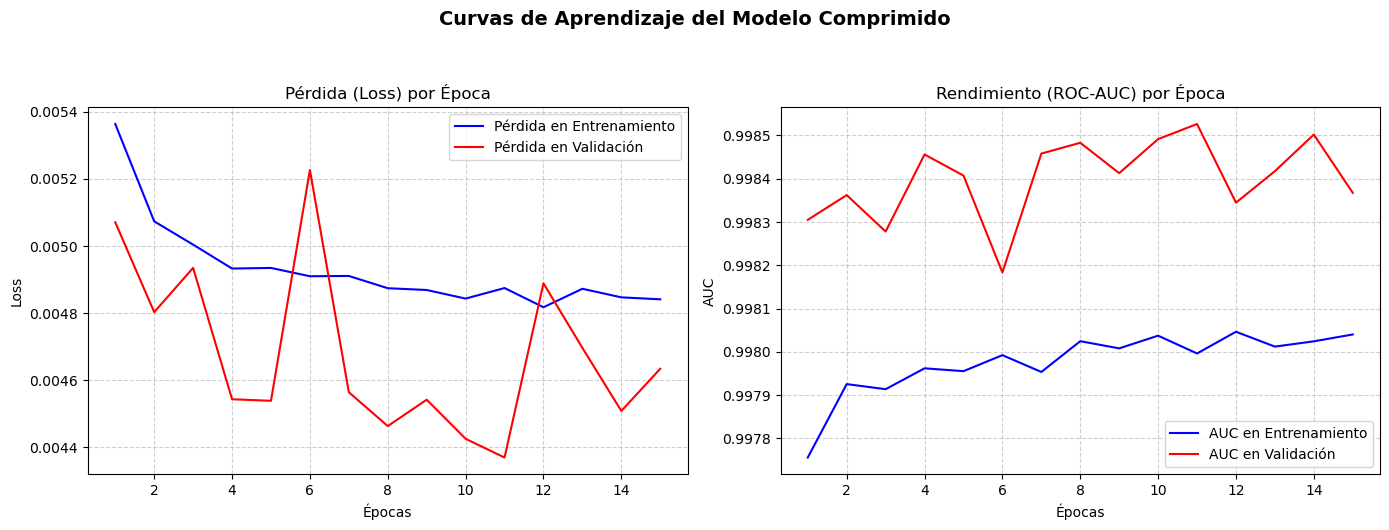

In [11]:
import matplotlib.pyplot as plt

def graficar_curvas_entrenamiento(history, titulo="Curvas de Aprendizaje del Modelo Comprimido"):
    """
    Grafica la función de pérdida (Loss) y la métrica principal (AUC) 
    para los conjuntos de entrenamiento y validación.
    """
    # Extraer datos del historial
    acc = history.history.get('auc') or history.history.get('auc_1') # Dependiendo del nombre en TF
    val_acc = history.history.get('val_auc') or history.history.get('val_auc_1')
    loss = history.history.get('loss') or history.history.get('student_loss')
    val_loss = history.history.get('val_loss') or history.history.get('val_student_loss')

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b-', label='Pérdida en Entrenamiento')
    if val_loss:
        plt.plot(epochs, val_loss, 'r-', label='Pérdida en Validación')
    plt.title('Pérdida (Loss) por Época')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Gráfico de Métrica (AUC)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'b-', label='AUC en Entrenamiento')
    if val_acc:
        plt.plot(epochs, val_acc, 'r-', label='AUC en Validación')
    plt.title('Rendimiento (ROC-AUC) por Época')
    plt.xlabel('Épocas')
    plt.ylabel('AUC')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Ejecución:
graficar_curvas_entrenamiento(history_qat)


📊 EVALUACIÓN: Base (Punto Flotante)
--- Análisis de Hardware: Base (Punto Flotante) ---
🔹 Parámetros Totales:   21,057
🔹 Parámetros Activos:   9,288 (Sparsity: 55.89%)
🔹 Tipo de Dato (Aprox): FP-32 (4 bytes)
⚡ Huella en Memoria BRAM (Aprox): 36.28 KB

⭐ ROC-AUC Score: 0.9977
----------------------------------------------------------------------
               precision    recall  f1-score   support

 Legítimo (0)     0.9864    0.9991    0.9928     98838
Malicioso (1)     0.9991    0.9863    0.9927     98838

     accuracy                         0.9927    197676
    macro avg     0.9928    0.9927    0.9927    197676
 weighted avg     0.9928    0.9927    0.9927    197676



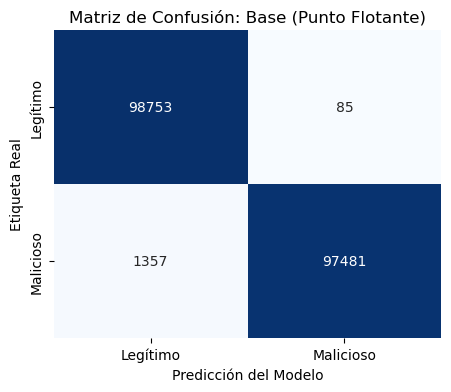


📊 EVALUACIÓN: Pruned + QAT (Sparsity 60% + 8-bits)
--- Análisis de Hardware: Pruned + QAT (Sparsity 60% + 8-bits) ---
🔹 Parámetros Totales:   21,057
🔹 Parámetros Activos:   10,358 (Sparsity: 50.81%)
🔹 Tipo de Dato (Aprox): INT-8 (1 byte)
⚡ Huella en Memoria BRAM (Aprox): 10.12 KB

⭐ ROC-AUC Score: 0.9982
----------------------------------------------------------------------
               precision    recall  f1-score   support

 Legítimo (0)     0.9878    0.9993    0.9935     98838
Malicioso (1)     0.9993    0.9877    0.9935     98838

     accuracy                         0.9935    197676
    macro avg     0.9936    0.9935    0.9935    197676
 weighted avg     0.9936    0.9935    0.9935    197676



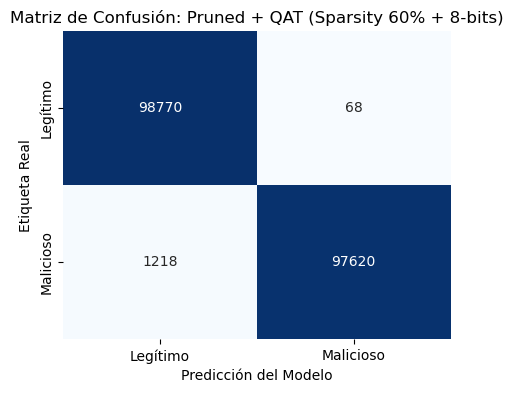

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analizar_parametros_hardware(modelo, nombre):
    """Cuenta parámetros totales, activos (no nulos) y estima huella de memoria."""
    total_params = 0
    active_params = 0
    
    for layer in modelo.layers:
        pesos = layer.get_weights()
        for p in pesos:
            total_params += np.size(p)
            active_params += np.count_nonzero(p)
            
    sparsity = 1.0 - (active_params / total_params) if total_params > 0 else 0
    
    # Estimación simple de memoria:
    # Punto flotante original = 32 bits (4 bytes). Modelo QAT = 8 bits (1 byte)
    es_cuantizado = "QAT" in nombre or "Estudiante" in nombre
    bytes_por_parametro = 1 if es_cuantizado else 4
    
    huella_kb = (active_params * bytes_por_parametro) / 1024
    
    print(f"--- Análisis de Hardware: {nombre} ---")
    print(f"🔹 Parámetros Totales:   {total_params:,}")
    print(f"🔹 Parámetros Activos:   {active_params:,} (Sparsity: {sparsity:.2%})")
    print(f"🔹 Tipo de Dato (Aprox): {'INT-8 (1 byte)' if es_cuantizado else 'FP-32 (4 bytes)'}")
    print(f"⚡ Huella en Memoria BRAM (Aprox): {huella_kb:.2f} KB\n")

def evaluar_y_comparar_modelos(dict_modelos, X_test, y_test):
    """
    Evalúa modelos, compara métricas y analiza su impacto en hardware.
    """
    for nombre, modelo in dict_modelos.items():
        print(f"\n{'='*70}")
        print(f"📊 EVALUACIÓN: {nombre}")
        print(f"{'='*70}")
        
        # 1. Perfilado de Hardware
        analizar_parametros_hardware(modelo, nombre)
        
        # 2. Inferencia
        probs = modelo.predict(X_test, batch_size=512, verbose=0).ravel()
        preds = (probs > 0.5).astype(int)
        
        # 3. Métricas
        auc_score = roc_auc_score(y_test, probs)
        print(f"⭐ ROC-AUC Score: {auc_score:.4f}")
        print("-" * 70)
        print(classification_report(y_test, preds, target_names=['Legítimo (0)', 'Malicioso (1)'], digits=4))
        
        # 4. Matriz de Confusión
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Legítimo', 'Malicioso'],
                    yticklabels=['Legítimo', 'Malicioso'])
        plt.title(f'Matriz de Confusión: {nombre}')
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Predicción del Modelo')
        plt.show()


evaluar_y_comparar_modelos({
    "Base (Punto Flotante)": base_model,
    "Pruned + QAT (Sparsity 60% + 8-bits)": qat_model
}, X_test, y_test)

In [13]:
# 5. Guardar modelo final para hls4ml
qat_model.save('modelo_pruned_qat.h5')

with open('modelo_pruned_qat_arch.json', 'w') as f:
    f.write(qat_model.to_json())
qat_model.save_weights('modelo_pruned_qat_weights.h5')

print('Guardado: modelo_pruned_qat.h5')
print('Guardado: modelo_pruned_qat_arch.json')
print('Guardado: modelo_pruned_qat_weights.h5')


Guardado: modelo_pruned_qat.h5
Guardado: modelo_pruned_qat_arch.json
Guardado: modelo_pruned_qat_weights.h5
